# Optimized Spin-Chain Notebook

This version keeps the fixed-σz XXZ workflow from the refactored notebook but rewrites the heavy path around integer bitmasks, cached cut maps, and selective entropy evaluation.

The symmetry-resolved full-basis branch is intentionally left out here because it does not scale to large chains. This notebook is meant for the fixed-N_parrow exact-diagonalization workflow that you want to push to the largest practical L.

Rule of thumb for a typical laptop: L pprox 20 is comfortable for the full workflow, L = 22 is borderline, and L e 24 is usually not reasonable unless you reduce the workload to a single cut and a very small number of parameter points.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from itertools import combinations
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import svdvals

try:
    from numba import njit
except Exception:
    def njit(*args, **kwargs):
        def decorator(func):
            return func
        return decorator


@njit(cache=True)
def _build_cut_map_numba(states, L, ell):
    dim = states.shape[0]
    row_a = np.empty(dim, dtype=np.int32)
    row_b = np.empty(dim, dtype=np.int32)
    left_shift = L - ell
    left_mask = (1 << left_shift) - 1
    right_mask = (1 << ell) - 1

    for i in range(dim):
        state = states[i]
        row_a[i] = (state >> left_shift) & left_mask
        row_b[i] = state & right_mask

    return row_a, row_b


@njit(cache=True)
def _build_hamiltonian_triplets(states, index_map, L, pairs1, pairs2, J1xy, J1z, J2xy, J2z, kind_flag):
    dim = states.shape[0]
    n1 = pairs1.shape[0]
    n2 = pairs2.shape[0]
    if kind_flag == 0:
        max_nnz = dim + dim * n1
    else:
        max_nnz = dim + dim * (n1 + n2)

    rows = np.empty(max_nnz, dtype=np.int32)
    cols = np.empty(max_nnz, dtype=np.int32)
    vals = np.empty(max_nnz, dtype=np.float64)
    diag = np.zeros(dim, dtype=np.float64)
    one = np.uint64(1)
    cursor = 0

    for i in range(dim):
        state = states[i]

        for p in range(n1):
            a = pairs1[p, 0]
            b = pairs1[p, 1]
            pa = np.uint64(L - 1 - a)
            pb = np.uint64(L - 1 - b)
            bit_a = (state >> pa) & one
            bit_b = (state >> pb) & one
            if bit_a == bit_b:
                diag[i] += J1z / 4.0
            else:
                diag[i] -= J1z / 4.0
                if J1xy != 0.0:
                    flipped = state ^ ((one << pa) | (one << pb))
                    j = index_map[np.int64(flipped)]
                    rows[cursor] = i
                    cols[cursor] = j
                    vals[cursor] = J1xy / 2.0
                    cursor += 1

        if kind_flag == 1:
            for p in range(n2):
                a = pairs2[p, 0]
                b = pairs2[p, 1]
                pa = np.uint64(L - 1 - a)
                pb = np.uint64(L - 1 - b)
                bit_a = (state >> pa) & one
                bit_b = (state >> pb) & one
                if bit_a == bit_b:
                    diag[i] += J2z / 4.0
                else:
                    diag[i] -= J2z / 4.0
                    if J2xy != 0.0:
                        flipped = state ^ ((one << pa) | (one << pb))
                        j = index_map[np.int64(flipped)]
                        rows[cursor] = i
                        cols[cursor] = j
                        vals[cursor] = J2xy / 2.0
                        cursor += 1

    for i in range(dim):
        rows[cursor] = i
        cols[cursor] = i
        vals[cursor] = diag[i]
        cursor += 1

    return rows[:cursor], cols[:cursor], vals[:cursor]


class FastXXZChain:
    """Optimized fixed-Nup XXZ chain with cached basis, Hamiltonian, and entropy maps."""

    def __init__(self, L, Nup, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.0, J2z=0.0):
        self.L = int(L)
        self.Nup = int(Nup)
        self.periodic = bool(periodic)
        self.J1xy = float(J1xy)
        self.J1z = float(J1z)
        self.J2xy = float(J2xy)
        self.J2z = float(J2z)

        self.states = self._build_basis_states()
        self.index_map = self._build_index_map()
        self.pairs1 = np.asarray(self._pairs(1), dtype=np.int32)
        self.pairs2 = np.asarray(self._pairs(2), dtype=np.int32)
        self._entropy_cache = {}

    def _build_basis_states(self):
        states = []
        for positions in combinations(range(self.L), self.Nup):
            value = 0
            for site in positions:
                value |= 1 << (self.L - 1 - site)
            states.append(value)
        return np.asarray(states, dtype=np.uint64)

    def _build_index_map(self):
        size = 1 << self.L
        index_map = -np.ones(size, dtype=np.int32)
        for i, state in enumerate(self.states):
            index_map[int(state)] = i
        return index_map

    def _pairs(self, order):
        if order == 1:
            if self.periodic:
                return [(i, (i + 1) % self.L) for i in range(self.L)]
            return [(i, i + 1) for i in range(self.L - 1)]
        if order == 2:
            if self.periodic:
                return [(i, (i + 2) % self.L) for i in range(self.L)]
            return [(i, i + 2) for i in range(self.L - 2)]
        raise ValueError('order must be 1 or 2')

    def hilbert_dimension(self):
        return int(self.states.size)

    def build_hamiltonian(self, kind='nnn'):
        if kind not in {'nn', 'nnn'}:
            raise ValueError("kind must be 'nn' or 'nnn'.")

        kind_flag = 0 if kind == 'nn' else 1
        rows, cols, vals = _build_hamiltonian_triplets(
            self.states,
            self.index_map,
            self.L,
            self.pairs1,
            self.pairs2,
            self.J1xy,
            self.J1z,
            self.J2xy,
            self.J2z,
            kind_flag,
        )
        dim = self.hilbert_dimension()
        return coo_matrix((vals, (rows, cols)), shape=(dim, dim)).tocsr()

    def ground_state(self, kind='nnn'):
        H = self.build_hamiltonian(kind=kind)
        if H.shape[0] == 1:
            return float(H[0, 0]), np.array([1.0], dtype=float)
        eigvals, eigvecs = eigsh(H, k=1, which='SA', tol=1e-12, maxiter=100000)
        return float(eigvals[0]), eigvecs[:, 0]

    def _cut_map(self, ell):
        if ell in self._entropy_cache:
            return self._entropy_cache[ell]

        row_a, row_b = _build_cut_map_numba(self.states, self.L, ell)
        mapping = {
            'rowA': row_a,
            'rowB': row_b,
            'dimA': 1 << ell,
            'dimB': 1 << (self.L - ell),
        }
        self._entropy_cache[ell] = mapping
        return mapping

    def entropy_curve(self, kind='nnn', blocks=None):
        ground_energy, sector_state = self.ground_state(kind=kind)
        if blocks is None:
            blocks = range(1, self.L)
        block_list = sorted({int(block) for block in blocks if 0 < block < self.L})

        entropies = np.zeros(len(block_list), dtype=float)
        for i, ell in enumerate(block_list):
            data = self._cut_map(ell)
            psi_matrix = np.zeros((data['dimA'], data['dimB']), dtype=complex)
            psi_matrix[data['rowA'], data['rowB']] = sector_state
            svals = svdvals(psi_matrix)
            probs = svals**2
            probs = probs[probs > 1e-14]
            entropies[i] = float(-np.sum(probs * np.log(probs)))

        block_sizes = np.asarray(block_list, dtype=int)
        upper_bound = np.log(2.0) * np.minimum(block_sizes, self.L - block_sizes)
        return block_sizes, entropies, upper_bound, ground_energy

    def plot_entropy(self, kind='nnn', blocks=None, title=None):
        block_sizes, entropies, upper_bound, ground_energy = self.entropy_curve(kind=kind, blocks=blocks)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(block_sizes, entropies, marker='o', linewidth=2, label='Entropy')
        ax.plot(block_sizes, upper_bound, '--', linewidth=2, label='Upper Bound')
        ax.set_xlabel('Block size l')
        ax.set_ylabel('S(l)')
        ax.set_title(title or f'Entanglement Entropy (E0 = {ground_energy:.6f})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


def half_filling_dimension(L):
    return comb(L, L // 2)


def recommended_max_L(limit_dim=200000):
    best = 0
    for L in range(2, 40, 2):
        if half_filling_dimension(L) <= limit_dim:
            best = L
    return best


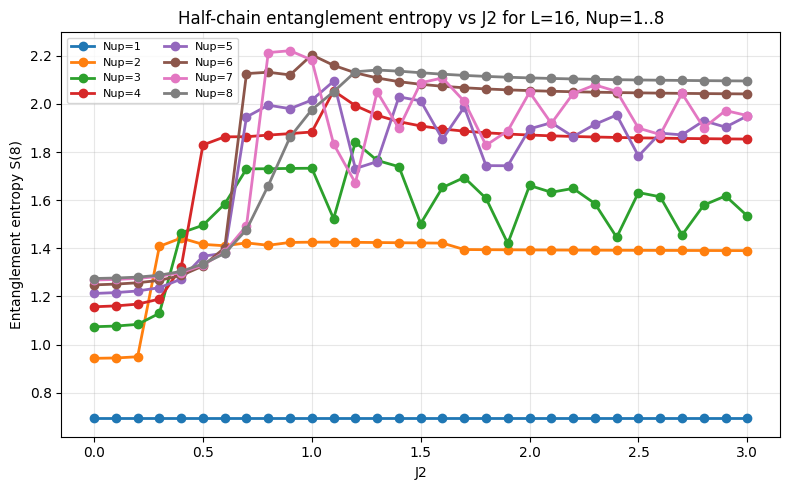

In [11]:
# Entanglement entropy vs J2, with one curve for each Nup = 1..L/2.
# The y-value is the half-chain entropy S(L/2).
L_plot = 16
Nup_values = range(1, L_plot // 2 + 1)
J2_scan = np.round(np.arange(0.0, 3.0 + 1e-9, 0.1), 1)
mid_block = L_plot // 2

fig, ax = plt.subplots(figsize=(8, 5))
for nup in Nup_values:
    chain = FastXXZChain(
        L=L_plot,
        Nup=nup,
        periodic=True,
        J1xy=1.0,
        J1z=0.5,
        J2xy=0.0,
        J2z=0.0,
    )

    entropy_vs_J2 = []
    for J2_val in J2_scan:
        chain.J2xy = float(J2_val)
        blocks, entropies, upper_bound, energy = chain.entropy_curve(kind="nnn", blocks=[mid_block])
        entropy_vs_J2.append(entropies[0])

    ax.plot(J2_scan, entropy_vs_J2, marker="o", linewidth=2, label=f"Nup={nup}")

ax.set_xlabel("J2")
ax.set_ylabel(f"Entanglement entropy S({mid_block})")
ax.set_title(f"Half-chain entanglement entropy vs J2 for L={L_plot}, Nup=1..{L_plot // 2}")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# Entanglement entropy vs J2, with one curve for each even L = 2..20.
# The y-value is the half-chain entropy S(L/2) at half filling.
L_values = range(2, 21, 2)
J2_scan = np.round(np.arange(0.0, 3.0 + 1e-9, 0.1), 1)

fig, ax = plt.subplots(figsize=(8, 5))
for chain_length in L_values:
    nup = chain_length // 2
    chain = FastXXZChain(
        L=chain_length,
        Nup=nup,
        periodic=True,
        J1xy=1.0,
        J1z=0.5,
        J2xy=0.0,
        J2z=0.0,
    )

    entropy_vs_J2 = []
    mid_block = chain_length // 2
    for J2_val in J2_scan:
        chain.J2xy = float(J2_val)
        blocks, entropies, upper_bound, energy = chain.entropy_curve(kind="nnn", blocks=[mid_block])
        entropy_vs_J2.append(entropies[0])

    ax.plot(J2_scan, entropy_vs_J2, marker="o", linewidth=2, label=f"L={chain_length}")

ax.set_xlabel("J2")
ax.set_ylabel("Half-chain entanglement entropy")
ax.set_title("Half-chain entanglement entropy vs J2 for even L = 2..20")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()
